In [4]:
# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")


from analytic.formulas import *

In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
import os
import json
import pandas as pd
import string
# Set the folder containing the JSON files
folder_path = "/Users/fabianhelmberger/gitrepos/clonscal/results/gaussian_sim_data/"

# List all JSON files in the folder
json_files = [f for f in os.listdir(folder_path) if f.endswith(".json")]

# Initialize a list to store data
data_list = []

histograms_p = {}
histograms_u = {}

# Loop through the JSON files and load them into a DataFrame
for idx, file in enumerate(json_files):
    file_path = os.path.join(folder_path, file)
       

    with open(file_path, "r") as f:
        data = json.load(f)

    # Flatten the structure
    flattened_data = {
        "steps": data["params"]["steps"],
        "trajs": data["params"]["trajs"],
        "dt": data["params"]["dt"],
        "sigma_abs": data["params"]["sigma_abs"],
        "sigma_phase": data["params"]["sigma_phase"],
        "lambda_abs": data["params"]["lambda_abs"],
        "mass_modification": data["params"]["mass_modification"],
        "pullback": data["params"]["pullback"],
        "bins_u": data["params"]["bins_u"],
        "bins_p": data["params"]["bins_p"],
        "p_min_real": data["params"]["p_min_real"],
        "p_max_real": data["params"]["p_max_real"],
        "p_min_imag": data["params"]["p_min_imag"],
        "p_max_imag": data["params"]["p_max_imag"],
        "u_min": data["params"]["u_min"],
        "u_max": data["params"]["u_max"],
    }

    # Add dse moment values
    for moment in ["dse_1_moment", "dse_2_moment", "dse_3_moment","dse_4_moment"]:
        for key in data[moment]:
            flattened_data[f"{moment}_{key}"] = data[moment][key]

    for moment in ["1_moment", "2_moment", "3_moment","4_moment"]:
        for key in data[moment]:
            flattened_data[f"{moment}_{key}"] = float(data[moment][key])
    flattened_data["idx"] = idx
    data_list.append(flattened_data)

    with open(file_path[:-5]+"_hist_p.npy", 'rb') as f:
        hist_p = np.load(f)
        histograms_p[idx] = hist_p

    with open(file_path[:-5]+"_hist_u.npy", 'rb') as f:
        hist_u = np.load(f)
        histograms_u[idx] = hist_u
    


# Create the DataFrame
df = pd.DataFrame(data_list)
df

,steps,trajs,dt,sigma_abs,sigma_phase,lambda_abs,mass_modification,pullback,bins_u,bins_p,...,dse_4_moment_sem_real,dse_4_moment_sem_imag,1_moment_sem_real,1_moment_sem_imag,2_moment_sem_real,2_moment_sem_imag,3_moment_sem_real,3_moment_sem_imag,4_moment_sem_real,4_moment_sem_imag
0,1000000,10000,0.00005,4.123106,1.815775,2,2.5,50,10000,1000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50000,500000,0.00100,4.123106,1.815775,2,2.5,100,10000,1000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1000000,10000,0.00005,4.123106,1.815775,2,10.0,200,10000,1000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000000,10000,0.00005,4.123106,1.815775,2,2.5,200,10000,1000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000000,10000,0.00005,4.123106,1.815775,2,2.5,100,10000,1000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1000000,10000,0.00005,4.123106,1.815775,2,5.0,50,10000,1000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,50000,500000,0.00100,4.123106,1.815775,2,2.5,200,10000,1000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1000000,10000,0.00005,4.123106,1.815775,2,10.0,100,10000,1000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,10000,10000,0.50000,4.123106,1.815775,2,2.5,200,10000,1000,...,0.016065,0.082644,0.000003,0.000162,0.000006,0.000215,0.000015,0.00055,0.000042,0.001322
9,50000,500000,0.00100,4.123106,1.815775,2,2.5,50,10000,1000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# solve_floweq
from scipy.integrate import solve_ivp

def stop_event(t, z, *args, **kwargs):
    x, y = z
    return max(x, y) - 10  # Triggers when either x or y reaches 10

stop_event.terminal = True

def solve_floweq(flow_equation, crit_point, epsilon = 0.001, t_span = (0, 100), t_points=10, events = None, **kwargs):
    sigma = kwargs.get("sigma", 5*np.exp(1j*np.pi*3/4)) 
    lamb = kwargs.get("lamb", 1) 
    pullback = kwargs.get("pullback", 1) 
    mass_modification = kwargs.get("mass_modification", 5)

    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = []
    flow_times = []
    
    directions_num = 4
    angles = np.linspace(0+0.01, 2*np.pi+0.01, directions_num, endpoint=False)
    perturbations = epsilon * np.exp(1j * angles)

    for perturb in perturbations:
        z0 = crit_point + perturb
        z0 = [np.real(crit_point + perturb), np.imag(crit_point + perturb)]

        solution = solve_ivp(flow_equation, t_span, y0 = z0, args = (sigma, lamb, pullback, mass_modification), t_eval=t_eval, method="BDF", events=stop_event)
        sol.append(solution.y[0] + 1j * solution.y[1])
        flow_times.append(solution.t)
    return sol, flow_times


In [8]:
# drift func

# gaussian mod
@np.vectorize
def drift_func(z, sigma, lamb, pullback, mass_modification):
    action = sigma/2*z**2+lamb/4*z**4
    mod = -mass_modification*z**2/2
    action_mod = action + mod
    drift = sigma*z+lamb*z**3

    if np.real(action_mod) < 0:
        return drift-pullback*(drift-mass_modification*z)*np.exp(action_mod) / (1+pullback*np.exp(action_mod))
    else: 
        return drift-pullback*(drift-mass_modification*z) / (np.exp(-action_mod)+pullback)

def flow_equation_stable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

def flow_equation_unstable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = -np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

In [9]:
# root finder

def F_real(z_real, sigma, lamb, pullback, mass_modification):
    z = z_real[0] + 1j * z_real[1]
    action = sigma/2*z**2+lamb/4*z**4
    mod = -mass_modification*z**2/2
    action_mod = action + mod
    drift = sigma*z+lamb*z**3

    if np.real(action_mod) < 0:
        out = drift-pullback*(drift-mass_modification*z)*np.exp(action_mod) / (1+pullback*np.exp(action_mod))
    else: 
        out =  drift-pullback*(drift-mass_modification*z) / (np.exp(-action_mod)+pullback)
    return np.array([out.real, out.imag])


from scipy.optimize import root as root_scipy

def find_roots(guess, sigma, lamb, pullback, mass_modification):
    sol = root_scipy(F_real, guess, method='hybr', args=(sigma, lamb, pullback, mass_modification))
    if sol.success:
        root_found = sol.x[0] + 1j * sol.x[1]
        return root_found
    return 0

In [10]:
# action
@np.vectorize
def action_mod(z, sigma, lamb, pullback, mass_modification):
    if np.real(np.log10(pullback)+sigma/2*z**2 + lamb/4*z**4 -mass_modification/2*z**2) > 100:
        return sigma/2*z**2 + lamb/4*z**4-np.log(pullback)*(sigma/2*z**2 + lamb/4*z**4 - mass_modification/2*z**2)  
    return sigma/2*z**2 + lamb/4*z**4-np.log(1+pullback*np.exp(sigma/2*z**2 + lamb/4*z**4 - mass_modification/2*z**2))

@np.vectorize
def action_unmod(z, sigma, lamb):
    return sigma/2*z**2+lamb/4*z**4

@np.vectorize
def drift_unmod(z, sigma, lamb):
    return sigma*z+lamb*z**3

In [11]:
# rebin
import numpy as np

def rebin_2d(hist, factor_x, factor_y):
    """
    Rebins a 2D histogram by summing over blocks of (factor_x, factor_y) bins.
    
    Parameters:
        hist (np.ndarray): The original 2D histogram (bins_x, bins_y).
        factor_x (int): Rebinning factor along x (real).
        factor_y (int): Rebinning factor along y (imag).

    Returns:
        np.ndarray: The rebinned histogram.
    """
    bins_x, bins_y = hist.shape
    new_bins_x = bins_x // factor_x
    new_bins_y = bins_y // factor_y
    
    # Ensure dimensions are divisible by factors (trim if necessary)
    hist = hist[:new_bins_x * factor_x, :new_bins_y * factor_y]
    
    # Reshape and sum over blocks
    rebinned_hist = hist.reshape(new_bins_x, factor_x, new_bins_y, factor_y).sum(axis=(1, 3))
    
    return rebinned_hist

def rebin_1d(hist, factor):
    """
    Rebins a 1D histogram by summing over blocks of `factor` bins.

    Parameters:
        hist (np.ndarray): The original 1D histogram (array of bin counts).
        factor (int): The number of adjacent bins to merge into one.

    Returns:
        np.ndarray: The rebinned histogram.
    """
    bins = len(hist)
    new_bins = bins // factor  # Compute the new number of bins

    # Trim the histogram if needed to ensure divisibility
    hist = hist[:new_bins * factor]

    # Reshape and sum over blocks
    rebinned_hist = hist.reshape(new_bins, factor).sum(axis=1)
    
    return rebinned_hist

$$
\tilde{\rho} = \rho + r e^{-a/2 x^2}
$$
$$
\tilde{S} = S - \log(1+r e^{-a/2 x^2} e^{S})
$$

In [12]:
df["2_moment_mean_real"]

0     0.389515
1     0.395529
2     0.101410
3     0.396874
4     0.394469
5     0.192734
6     0.397931
7     0.105123
8     0.854008
9     0.390498
10    0.195966
11    0.105161
12    0.192937
13    0.197955
14    0.194773
15    0.112771
16    0.197856
17    0.114120
18    0.101819
Name: 2_moment_mean_real, dtype: float64

### 1_dse moment and 2 moment results

5e-05
r = [50]  a = [2.5]
scipy 2 moment: (0.39008-0.001076j)
CL    2 moment: (0.389515-0.00102j)     pm  0.0008
scipy 1 dse moment: (0.457857-1.574314j)
CL    1 dse moment: (0.458423-1.57246j)     pm  0.004997


5e-05
r = [100]  a = [2.5]
scipy 2 moment: (0.395006-0.000505j)
CL    2 moment: (0.394469-0.00052j)     pm  0.000805
scipy 1 dse moment: (0.449076-1.587145j)
CL    1 dse moment: (0.447154-1.584982j)     pm  0.005017


5e-05
r = [200]  a = [2.5]
scipy 2 moment: (0.397495-0.000244j)
CL    2 moment: (0.396874-0.000267j)     pm  0.000804
scipy 1 dse moment: (0.444575-1.59357j)
CL    1 dse moment: (0.446803-1.590946j)     pm  0.00498


5e-05
r = [50]  a = [5.]
scipy 2 moment: (0.189472-0.005652j)
CL    2 moment: (0.192734-0.011406j)     pm  0.000393
scipy 1 dse moment: (0.959796-0.766851j)
CL    1 dse moment: (0.926537-0.756041j)     pm  0.001754


5e-05
r = [100]  a = [5.]
scipy 2 moment: (0.194662-0.002796j)
CL    2 moment: (0.194773-0.004411j)     pm  0.000395
scipy 1 dse moment

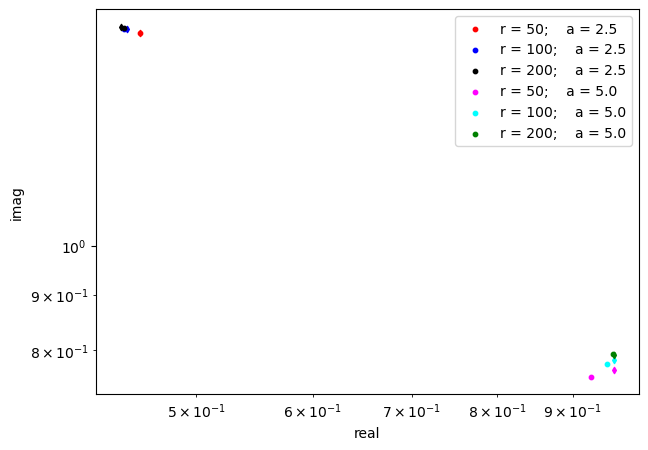

In [13]:
fig, ax = plt.subplots(1, figsize=(7, 5))

cols = ["red", "blue", "black", "magenta", "cyan", "green"]
for col, ((sigma_abs, sigma_phase, lambda_abs, mass_modification, pullback, dt), group) in zip(cols, df[df["dt"]==5e-5].groupby(["sigma_abs", "sigma_phase", "lambda_abs", "mass_modification", "pullback", "dt"])):
    print(dt)
    if dt == 5e-5:
        sigma = sigma_abs*np.exp(1j*sigma_phase)
        idx = group["idx"].unique()[0]
        hist_p = histograms_p[idx]
        hist_u = histograms_u[idx]
        p_min_real = group["p_min_real"].unique()[0]
        p_max_real = group["p_max_real"].unique()[0]
        p_min_imag = group["p_min_imag"].unique()[0]
        p_max_imag = group["p_max_imag"].unique()[0]
        dt = group["dt"].unique()[0]
        trajs = group["trajs"].unique()[0]
        steps = group["steps"].unique()[0]

        ana2 = n_moment_expval_gaussianmod(2, sigma, lambda_abs, pullback, mass_modification)
        ana1_dse = dse_n_moment_expval_gaussianmod(1, sigma, lambda_abs, pullback, mass_modification)

        cl2_mean, cl2_sem = group["2_moment_mean_real"].values[0]+1j*group["2_moment_mean_imag"].values[0], group["2_moment_sem"].values[0]
        cl1_dse_mean, cl1_dse_sem = group["dse_1_moment_mean_real"].values[0]+1j*group["dse_1_moment_mean_imag"].values[0], group["dse_1_moment_sem"].values[0]
        
        print(f"r = {group['pullback'].values}  a = {group['mass_modification'].values}")
        print(f"scipy 2 moment: {np.round(ana2, 6)}")
        print(f"CL    2 moment: {np.round(cl2_mean, 6)}     pm  {np.round(cl2_sem, 6)}")
        print(f"scipy 1 dse moment: {np.round(ana1_dse, 6)}")
        print(f"CL    1 dse moment: {np.round(cl1_dse_mean, 6)}     pm  {np.round(cl1_dse_sem, 6)}")
        
        print("\n")
        # ax.errorbar(np.abs(cl2_mean.real), np.abs(cl2_mean.imag), yerr=np.sqrt(cl2_sem), xerr=np.sqrt(cl2_sem), fmt='o', color='black', markersize=2, capsize=3)
        ax.scatter(np.abs(cl1_dse_mean.real), np.abs(cl1_dse_mean.imag), color = col, s = 10, label=f"r = {pullback};    a = {mass_modification}")
        ax.scatter(np.abs(ana1_dse.real), np.abs(ana1_dse.imag), color = col, s = 10, marker="d")
        
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_ylabel("imag")
    ax.set_xlabel("real")
    ax.legend()

r = [50]  a = [2.5]
scipy 2 moment: (0.39008-0.001076j)
CL    2 moment: (0.389515-0.00102j)     pm  0.0008
scipy 1 dse moment: (0.457857-1.574314j)
CL    1 dse moment: (0.458423-1.57246j)     pm  0.004997


r = [100]  a = [2.5]
scipy 2 moment: (0.395006-0.000505j)
CL    2 moment: (0.394469-0.00052j)     pm  0.000805
scipy 1 dse moment: (0.449076-1.587145j)
CL    1 dse moment: (0.447154-1.584982j)     pm  0.005017


r = [200]  a = [2.5]
scipy 2 moment: (0.397495-0.000244j)
CL    2 moment: (0.396874-0.000267j)     pm  0.000804
scipy 1 dse moment: (0.444575-1.59357j)
CL    1 dse moment: (0.446803-1.590946j)     pm  0.00498


r = [50]  a = [5.]
scipy 2 moment: (0.189472-0.005652j)
CL    2 moment: (0.192734-0.011406j)     pm  0.000393
scipy 1 dse moment: (0.959796-0.766851j)
CL    1 dse moment: (0.926537-0.756041j)     pm  0.001754


r = [100]  a = [5.]
scipy 2 moment: (0.194662-0.002796j)
CL    2 moment: (0.194773-0.004411j)     pm  0.000395
scipy 1 dse moment: (0.960068-0.783283j)
CL    1

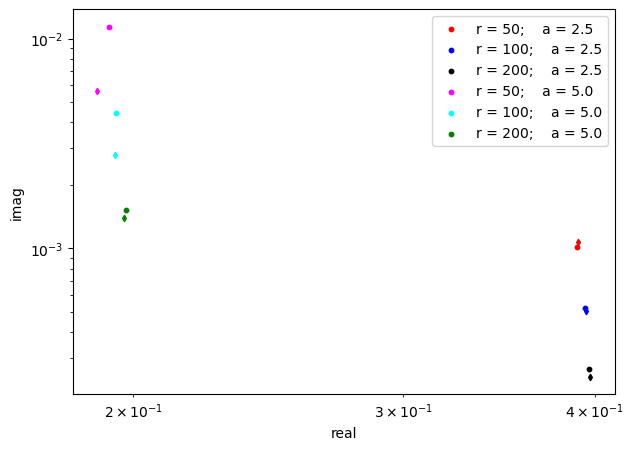

In [14]:
fig, ax = plt.subplots(1, figsize=(7, 5))

cols = ["red", "blue", "black", "magenta", "cyan", "green"]
for col, ((sigma_abs, sigma_phase, lambda_abs, mass_modification, pullback, dt), group) in zip(cols, df[df["dt"]==5e-5].groupby(["sigma_abs", "sigma_phase", "lambda_abs", "mass_modification", "pullback", "dt"])):
    if dt == 5e-5:
        sigma = sigma_abs*np.exp(1j*sigma_phase)
        idx = group["idx"].unique()[0]
        hist_p = histograms_p[idx]
        hist_u = histograms_u[idx]
        p_min_real = group["p_min_real"].unique()[0]
        p_max_real = group["p_max_real"].unique()[0]
        p_min_imag = group["p_min_imag"].unique()[0]
        p_max_imag = group["p_max_imag"].unique()[0]
        dt = group["dt"].unique()[0]
        trajs = group["trajs"].unique()[0]
        steps = group["steps"].unique()[0]

        ana2 = n_moment_expval_gaussianmod(2, sigma, lambda_abs, pullback, mass_modification)
        ana1_dse = dse_n_moment_expval_gaussianmod(1, sigma, lambda_abs, pullback, mass_modification)

        cl2_mean, cl2_sem = group["2_moment_mean_real"].values[0]+1j*group["2_moment_mean_imag"].values[0], group["2_moment_sem"].values[0]
        cl1_dse_mean, cl1_dse_sem = group["dse_1_moment_mean_real"].values[0]+1j*group["dse_1_moment_mean_imag"].values[0], group["dse_1_moment_sem"].values[0]
        
        print(f"r = {group['pullback'].values}  a = {group['mass_modification'].values}")
        print(f"scipy 2 moment: {np.round(ana2, 6)}")
        print(f"CL    2 moment: {np.round(cl2_mean, 6)}     pm  {np.round(cl2_sem, 6)}")
        print(f"scipy 1 dse moment: {np.round(ana1_dse, 6)}")
        print(f"CL    1 dse moment: {np.round(cl1_dse_mean, 6)}     pm  {np.round(cl1_dse_sem, 6)}")
        
        print("\n")
        # ax.errorbar(np.abs(cl2_mean.real), np.abs(cl2_mean.imag), yerr=np.sqrt(cl2_sem), xerr=np.sqrt(cl2_sem), fmt='o', color='black', markersize=2, capsize=3)
        ax.scatter(np.abs(cl2_mean.real), np.abs(cl2_mean.imag), color = col, s = 10, label=f"r = {pullback};    a = {mass_modification}")
        ax.scatter(np.abs(ana2.real), np.abs(ana2.imag), color = col, s = 10, marker="d")
        
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_ylabel("imag")
    ax.set_xlabel("real")
    ax.legend()

In [15]:
import numpy as np
from scipy.integrate import quad
from numba import jit

# define obs that vanishes wrt rho
def n_moment_dse(x, order, sigma, lamb):
    return order*x**(order-1)-x**order * (sigma * x + lamb * x*x*x)

def n_moment(x, order):
    return x**order


# define rho and R
@jit
def action(x, sigma, lamb): return sigma/2*x**2+lamb/4*x**4

@jit
def rho(x, sigma, lamb): return np.exp(-action(x, sigma, lamb))

@jit
def R(x, r, a): return r*np.exp(-a*x**2/2)

@jit
def rho_tilde(x, r, a, sigma, lamb): return rho(x, sigma, lamb)+R(x, r, a)

# define partition sums
def z_rho(sigma, lamb): 
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

def z_rho_tilde(r, a, sigma, lamb): 
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

def z_R(r, a, sigma, lamb): 
    real_part = quad(lambda x: np.real(R(x, r, a)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

# define exp val of n_moment_dse wrt rho_tilde
@np.vectorize
def n_moment_dse_rho_tilde(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho_tilde(r, a, sigma, lamb)
    
# define exp val of n_moment_dse wrt rho
@np.vectorize
def n_moment_dse_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

# define exp val of n_moment_dse wrt R
@np.vectorize
def n_moment_dse_R(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_R(r, a, sigma, lamb)

     
import scipy
# define analytic resul for n_moment_dse wrt R
@np.vectorize
def n_moment_dse_R_analytic(order, r, a, sigma, lamb):
    if order > 1:
        out = order*scipy.special.factorial2(order-2)/np.power(a, (order-1)//2)
    else: 
        out = 1
    out -= sigma*scipy.special.factorial2(order)/ np.power(a, (order+1)//2) 
    out -= lamb*scipy.special.factorial2(order+2)/np.power(a, (order+3)//2)
    return out

# define exp val of n_moment wrt rho
@np.vectorize
def n_moment_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

@np.vectorize
def n_moment_rho_tilde(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho_tilde(r, a, sigma, lamb)

@np.vectorize
def n_moment_R(order, r, a):
    real_part = quad(lambda x: np.real(R(x, r, a)*n_moment(x, order)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)*n_moment(x, order)), -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_R(r, a, 0, 0)

### scipy bias correction

r = [50]  a = [2.5]
Q CL:    (31.7529+37.88698j)
Q scipy: (32.96651+40.74374j)
bias corrected 2nd moment CL:    (0.09524-0.43063j)
bias corrected 2nd moment scipy: (0.10688-0.44071j)
mean is off by: 3.395%


r = [100]  a = [2.5]
Q CL:    (74.4588+65.24505j)
Q scipy: (65.93302+81.48747j)
bias corrected 2nd moment CL:    (0.01656-0.40016j)
bias corrected 2nd moment scipy: (0.10688-0.44071j)
mean is off by: 21.831%


r = [200]  a = [2.5]
Q CL:    (88.6148+115.9279j)
Q scipy: (131.86605+162.97494j)
bias corrected 2nd moment CL:    (0.15075-0.38635j)
bias corrected 2nd moment scipy: (0.10688-0.44071j)
mean is off by: 15.404000000000002%


r = [50]  a = [5.]
Q CL:    (21.04705+5.05553j)
Q scipy: (23.31084+28.81017j)
bias corrected 2nd moment CL:    (0.09747-0.2882j)
bias corrected 2nd moment scipy: (0.10688-0.44071j)
mean is off by: 33.694%


r = [100]  a = [5.]
Q CL:    (43.77045+23.19132j)
Q scipy: (46.62169+57.62034j)
bias corrected 2nd moment CL:    (0.06829-0.31868j)
bias corrected 2nd 

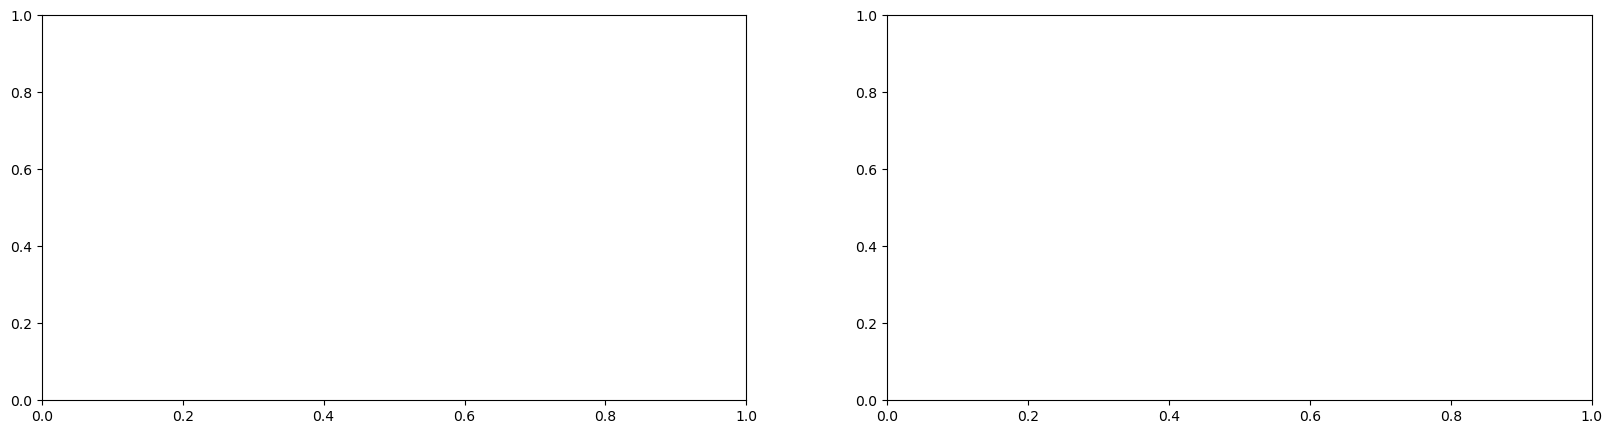

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

for (sigma_abs, sigma_phase,lambda_abs, mass_modification, pullback, dt), group in df.groupby(["sigma_abs", "sigma_phase", "lambda_abs", "mass_modification", "pullback", "dt"]):
    if dt == 5e-5:
        sigma = sigma_abs*np.exp(1j*sigma_phase)
        idx = group["idx"].unique()[0]
        hist_p = histograms_p[idx]
        hist_u = histograms_u[idx]
        p_min_real = group["p_min_real"].unique()[0]
        p_max_real = group["p_max_real"].unique()[0]
        p_min_imag = group["p_min_imag"].unique()[0]
        p_max_imag = group["p_max_imag"].unique()[0]
        dt = group["dt"].unique()[0]
        trajs = group["trajs"].unique()[0]
        steps = group["steps"].unique()[0]

        ana2 = n_moment_expval_gaussianmod(2, sigma, lambda_abs, pullback, mass_modification)
        ana1_dse = dse_n_moment_expval_gaussianmod(1, sigma, lambda_abs, pullback, mass_modification)

        cl2_mean, cl2_sem = group["2_moment_mean_real"].values[0]+1j*group["2_moment_mean_imag"].values[0], group["2_moment_sem"].values[0]
        cl1_dse_mean, cl1_dse_sem = group["dse_1_moment_mean_real"].values[0]+1j*group["dse_1_moment_mean_imag"].values[0], group["dse_1_moment_sem"].values[0]
        
        Q_cl = 1 / (n_moment_dse_R(1, pullback, mass_modification, sigma, lambda_abs)/cl1_dse_mean-1)
        Q_ana = 1/(n_moment_dse_R(1, pullback, mass_modification, sigma, lambda_abs)/n_moment_dse_rho_tilde(1, pullback, mass_modification, sigma, lambda_abs)-1)
        bias_corr_2_moment_cl = cl2_mean + (cl2_mean -n_moment_R(2, pullback, mass_modification))*Q_cl
        bias_corr_2_moment = n_moment_rho_tilde(2, pullback, mass_modification, sigma, lambda_abs) + (n_moment_rho_tilde(2, pullback, mass_modification, sigma, lambda_abs) -n_moment_R(2, pullback, mass_modification))*Q_ana

        print(f"r = {group['pullback'].values}  a = {group['mass_modification'].values}")
        print(f"Q CL:    {np.round(Q_cl,5)}")
        print(f"Q scipy: {np.round(Q_ana,5)}")
        print(f"bias corrected 2nd moment CL:    {np.round(bias_corr_2_moment_cl,5)}")
        print(f"bias corrected 2nd moment scipy: {np.round(n_moment_rho(2, sigma, lambda_abs),5)}")
        print(f"mean is off by: {np.round(np.abs((n_moment_rho(2, sigma, lambda_abs) - bias_corr_2_moment_cl)/n_moment_rho(2, sigma, lambda_abs)),5)*100}%")
        
        print("\n")


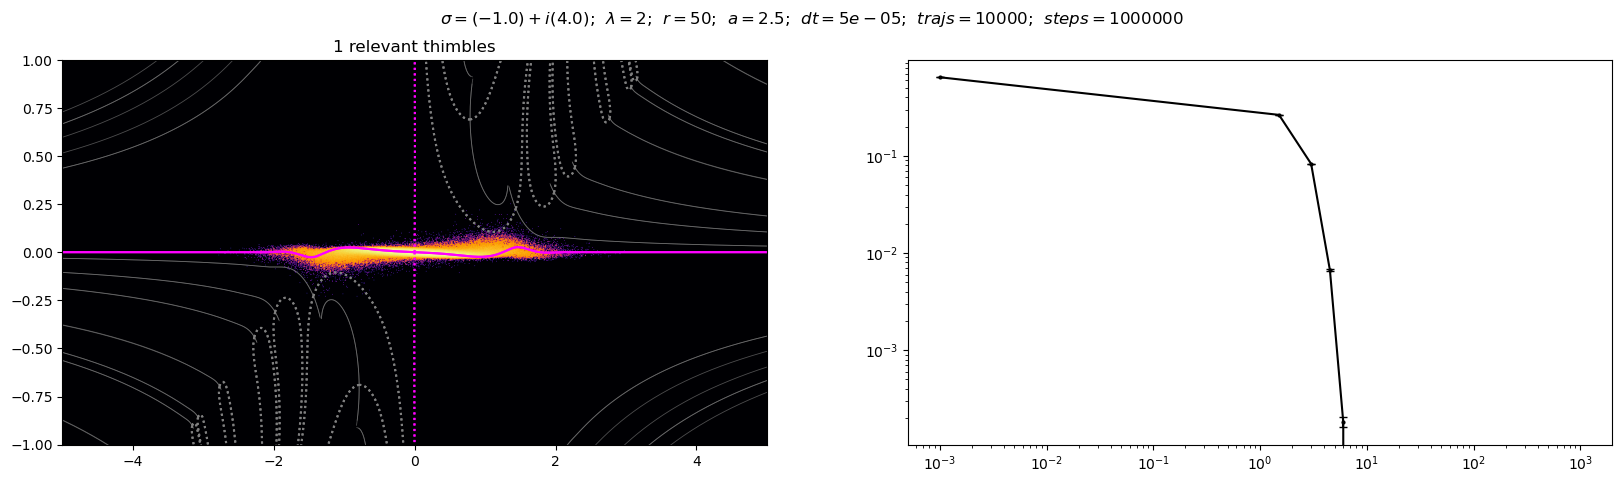

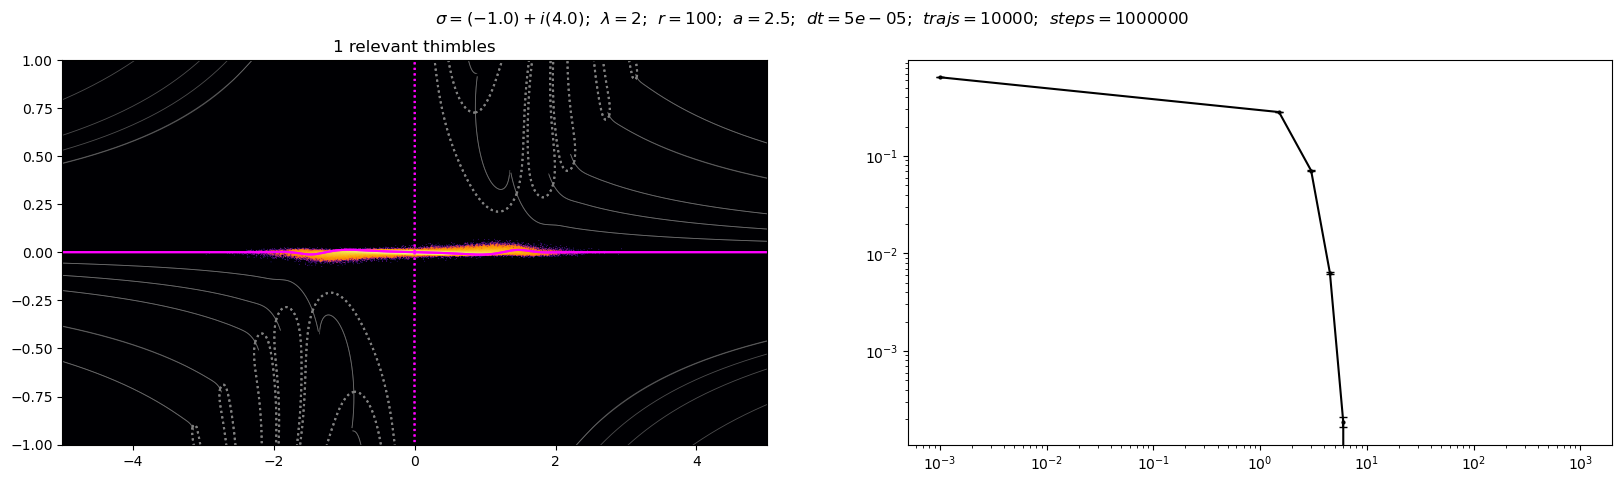

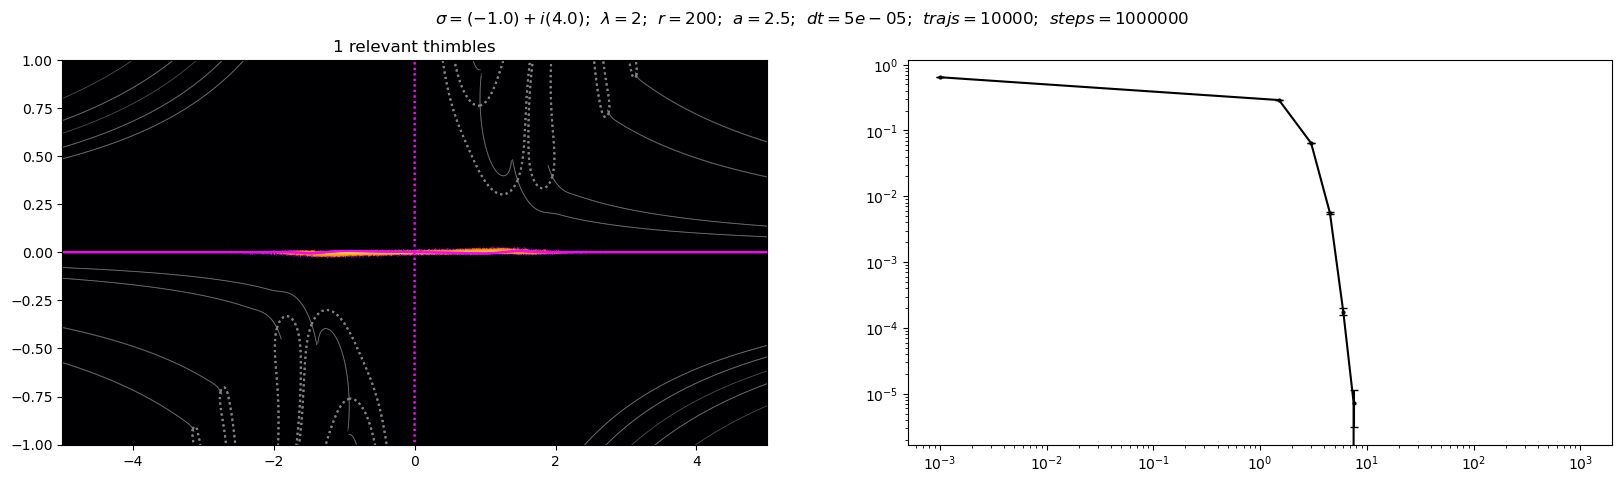

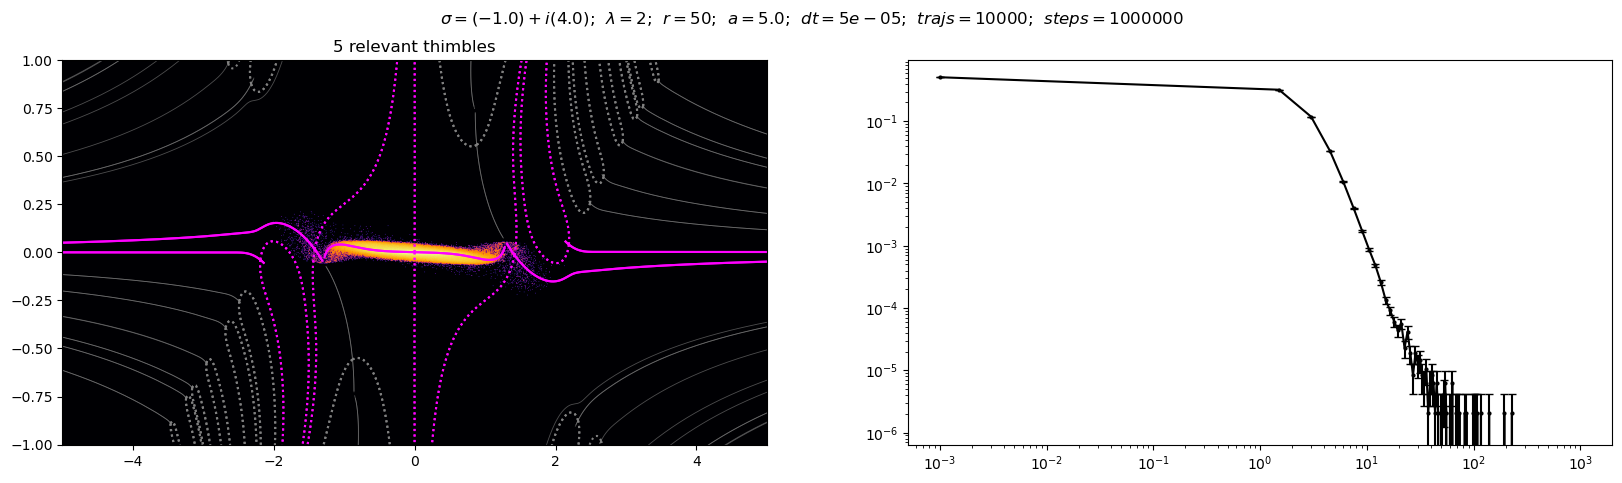

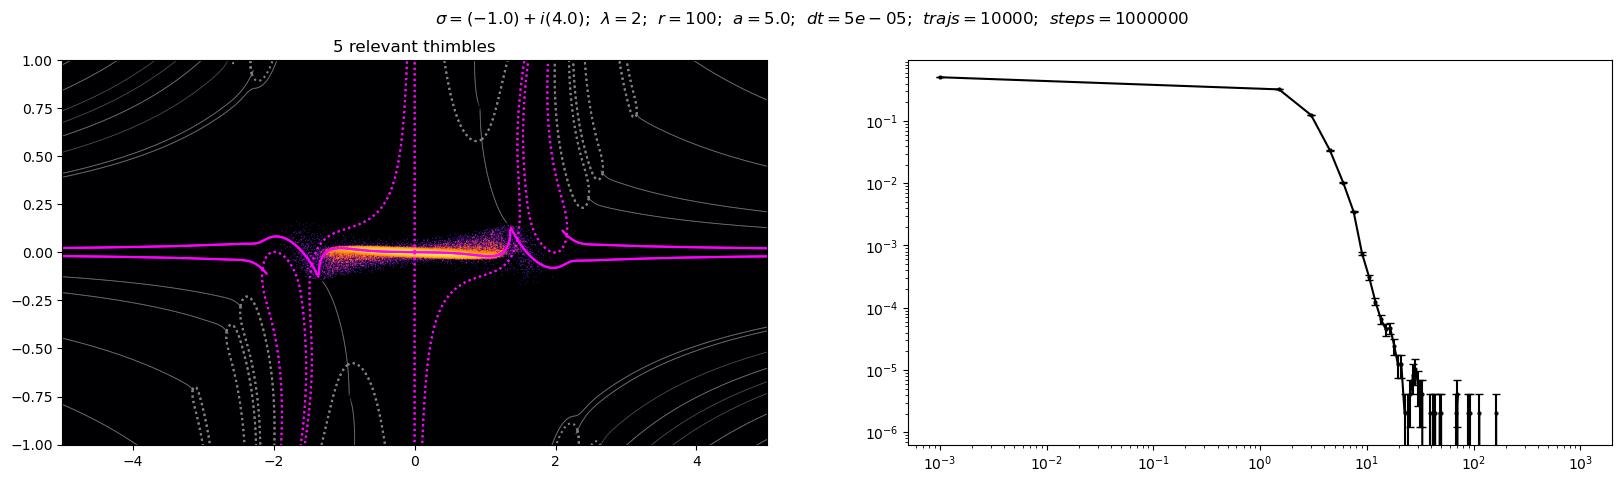

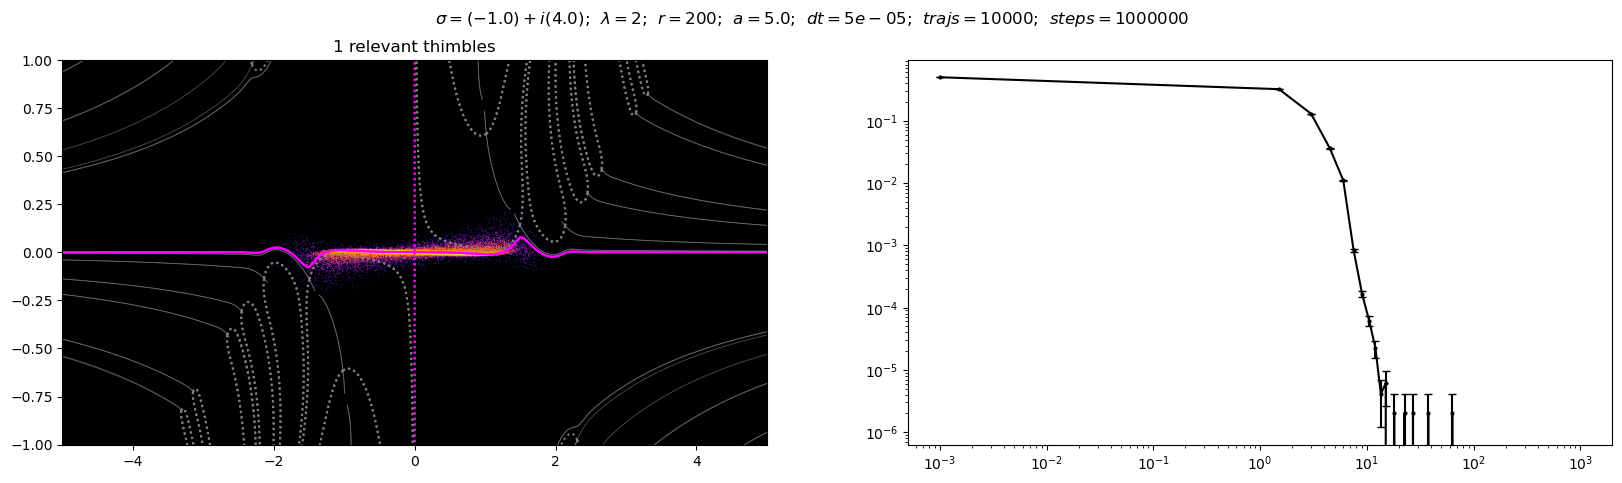

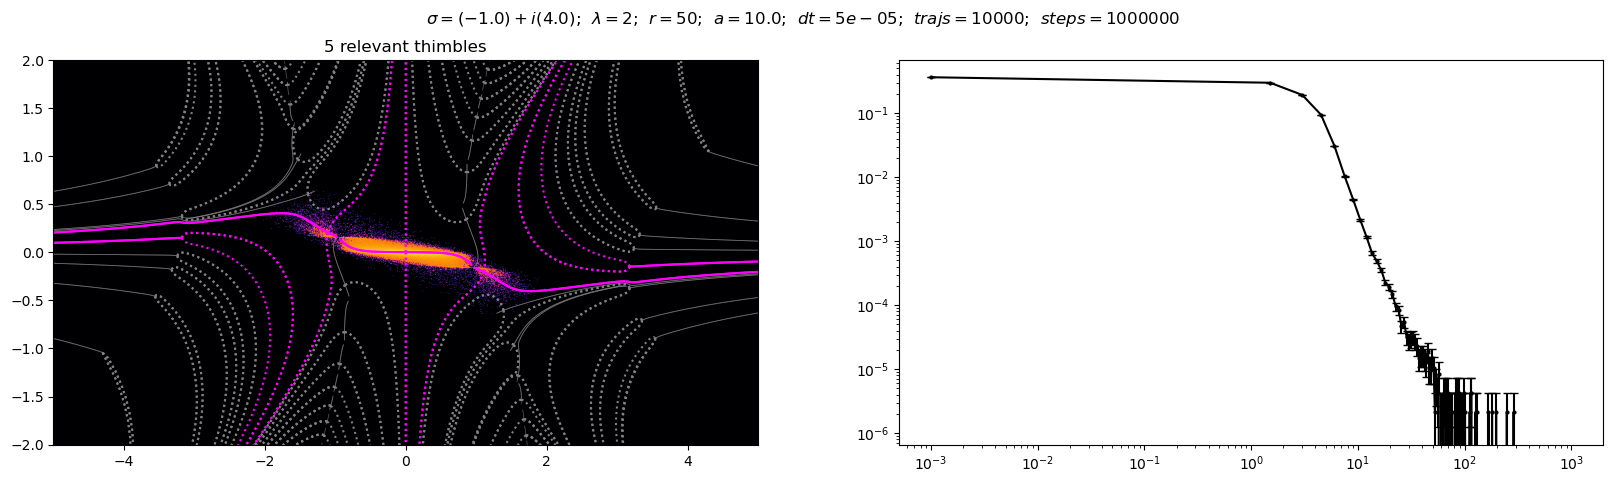

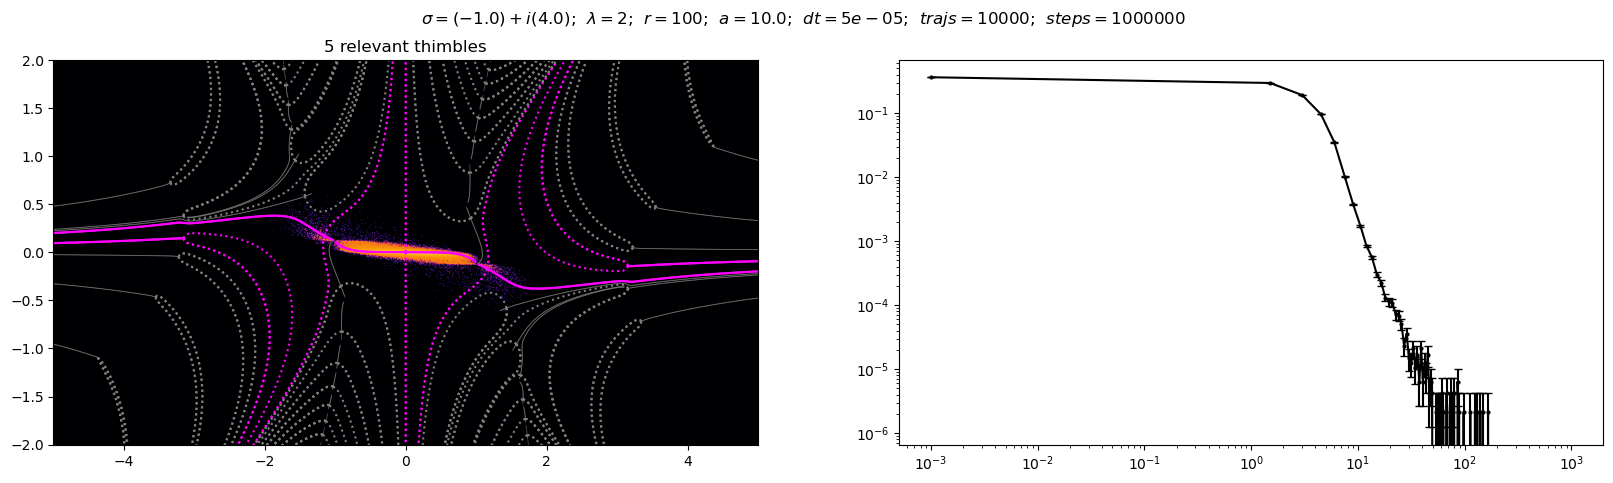

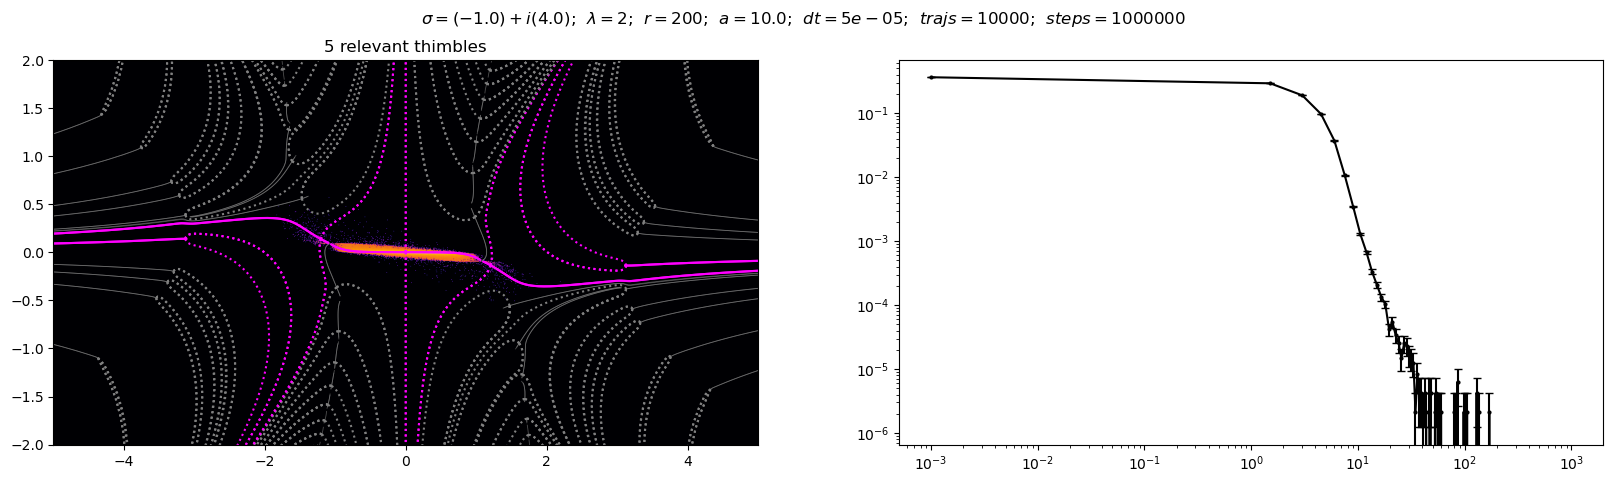

In [17]:
import matplotlib.cm as cm

for (sigma_abs, sigma_phase, lambda_abs, mass_modification, pullback, dt), group in df.groupby(["sigma_abs", "sigma_phase", "lambda_abs", "mass_modification", "pullback", "dt"]):
    if dt == 5e-5:
        
        sigma = sigma_abs*np.exp(1j*sigma_phase)
        idx = group["idx"].unique()[0]
        hist_p = histograms_p[idx]
        hist_u = histograms_u[idx]
        p_min_real = group["p_min_real"].unique()[0]
        p_max_real = group["p_max_real"].unique()[0]
        p_min_imag = group["p_min_imag"].unique()[0]
        p_max_imag = group["p_max_imag"].unique()[0]
        dt = group["dt"].unique()[0]
        trajs = group["trajs"].unique()[0]
        steps = group["steps"].unique()[0]

        fig, ax = plt.subplots(1, 2, figsize=(20, 5))
        fig.suptitle(rf"$\sigma = ({{{np.real(sigma)}}}) + i({{{np.imag(sigma)}}})$;  $\lambda = {{{lambda_abs}}}$;  $r = {{{pullback}}}$;  $a = {{{mass_modification}}}$;  $dt = {{{dt}}}$;  $trajs = {{{trajs}}}$;  $steps = {{{steps}}}$")
        hist_u = rebin_1d(hist_u, 15)
        hist_u_norm = hist_u / np.sum(hist_u)

        errors = np.sqrt(hist_u) / np.sum(hist_u)  # Normalize errors

        U_min, U_max = 0.001, 1000.0
        U_bins = np.linspace(U_min, U_max, len(hist_u_norm))
        U_centers = 0.5 * (U_bins[:-1] + U_bins[1:])  # Bin centers
        ax[1].errorbar(U_bins, hist_u_norm, yerr=errors, fmt='o', color='black', markersize=2, capsize=3)
        ax[1].plot(U_bins, hist_u_norm,color='black')
        ax[1].set_yscale("log")
        ax[1].set_xscale("log")

        # Create the figure and axis
        ax[0].imshow(np.log10(hist_p.T+1e-6), origin='lower', aspect='auto', extent=[p_min_real, p_max_real, p_min_imag, p_max_imag], cmap='inferno')

        # Thimbles
        x_vals = np.linspace(-5, 5, 50)  # Real part of z
        y_vals = np.linspace(-5, 5, 50)  # Imaginary part of z
        initial_guesses = [(x, y) for x in x_vals for y in y_vals]
        roots = []
        for guess in initial_guesses:
            root_found = find_roots(guess,sigma = sigma, lamb=lambda_abs, pullback=pullback, mass_modification=mass_modification)
            if not any(np.isclose(root_found, r, atol=1e-6) for r in roots):
                roots.append(root_found)
        
        num_relevant = 0
        cols_idx = np.linspace(0, 1, len(roots))

        for roo, col in zip(roots,  cm.rainbow(cols_idx)):
            # print(f"drift zero: {roo}")
            solutions, flow_times = solve_floweq(flow_equation_unstable, crit_point=roo, t_span = (0, 100), t_points=100000, 
                                    sigma = sigma, lamb=lambda_abs, pullback=pullback, mass_modification=mass_modification)
                    
            relevant = False
            conc_sol = np.concatenate(solutions, axis = 0)
            if any(conc_sol.imag>0) and any(conc_sol.imag<0): relevant = True; num_relevant += 1

            for sol in solutions:
                if relevant:
                    ax[0].plot(sol.real, sol.imag, color = "magenta", ls = ':')  # Set transparency for better visibility
                else:
                    ax[0].plot(sol.real, sol.imag, color = 'gray', ls = ':')  # Set transparency for better visibility

            # stable
            solutions, flow_times = solve_floweq(flow_equation_stable, crit_point=roo, t_span = (0, 100), t_points=100000, 
                                                sigma = sigma, lamb=lambda_abs, pullback=pullback, mass_modification=mass_modification)
            for sol, fl_time in zip(solutions, flow_times):
                # ax[1].set_title(len(solutions))
                if relevant:
                    # print(f"minimal action: {np.min(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                    # print(f"maximal action: {np.max(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                    ax[0].plot(sol.real, sol.imag, color = "magenta", ls = "solid")
                    # ax[1].scatter(fl_time,(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification))), s=1, color = col)
                else:
                    ax[0].plot(sol.real, sol.imag, color = 'gray', ls = "solid", alpha=0.6, lw = 0.6)  # Set transparency for better visibility
            ax[0].set_title(f"{num_relevant} relevant thimbles")
            ax[0].set_xlim(p_min_real, p_max_real)
            ax[0].set_ylim(p_min_imag, p_max_imag)

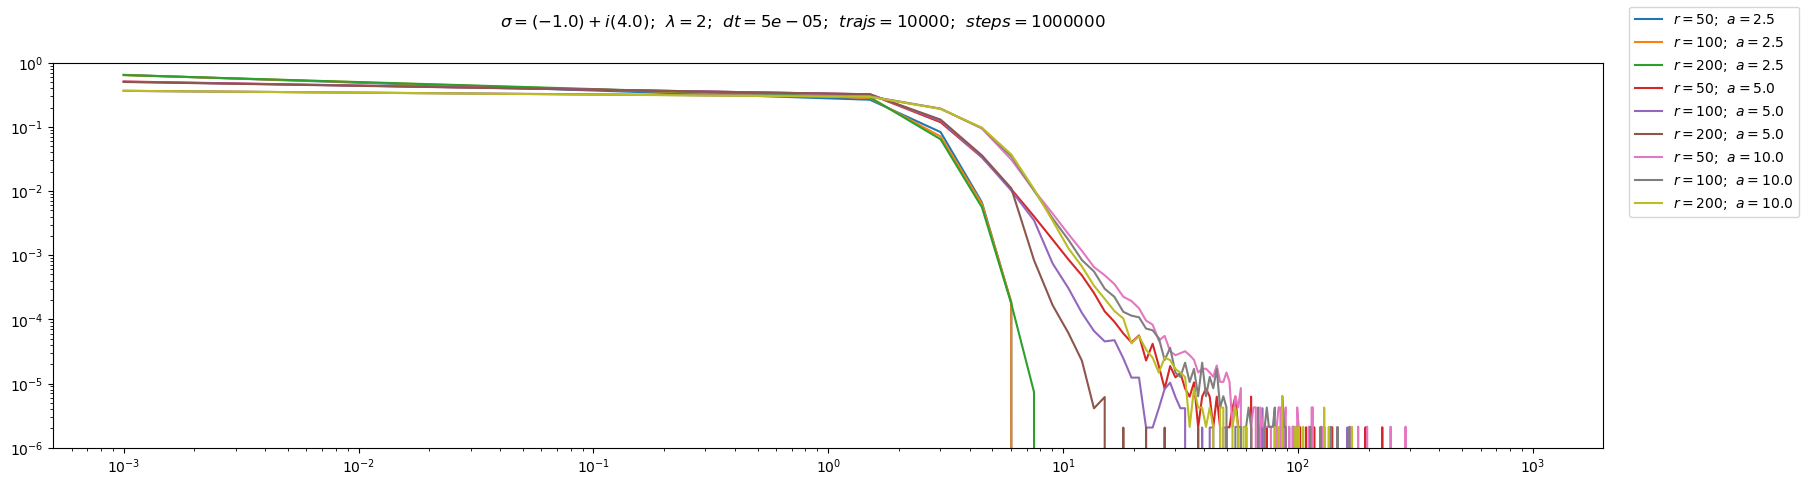

In [18]:
import matplotlib.cm as cm

fig, ax = plt.subplots(1, figsize=(20, 5))

for (sigma_abs, sigma_phase, lambda_abs, mass_modification, pullback, dt), group in df.groupby(["sigma_abs", "sigma_phase", "lambda_abs", "mass_modification", "pullback", "dt"]):
    if dt == 5e-5:
        
        sigma = sigma_abs*np.exp(1j*sigma_phase)
        idx = group["idx"].unique()[0]
        hist_p = histograms_p[idx]
        hist_u = histograms_u[idx]
        p_min_real = group["p_min_real"].unique()[0]
        p_max_real = group["p_max_real"].unique()[0]
        p_min_imag = group["p_min_imag"].unique()[0]
        p_max_imag = group["p_max_imag"].unique()[0]
        u_min = group["u_min"].unique()[0]
        u_max = group["u_max"].unique()[0]
        p_max_imag = group["p_max_imag"].unique()[0]
        dt = group["dt"].unique()[0]
        trajs = group["trajs"].unique()[0]
        steps = group["steps"].unique()[0]

        fig.suptitle(rf"$\sigma = ({{{np.real(sigma)}}}) + i({{{np.imag(sigma)}}})$;  $\lambda = {{{lambda_abs}}}$;  $dt = {{{dt}}}$;  $trajs = {{{trajs}}}$;  $steps = {{{steps}}}$")
        hist_u = rebin_1d(hist_u, 15)
        hist_u_norm = hist_u / np.sum(hist_u)

        errors = np.sqrt(hist_u) / np.sum(hist_u)  # Normalize errors

        U_bins = np.linspace(u_min, u_max, len(hist_u_norm))
        U_centers = 0.5 * (U_bins[:-1] + U_bins[1:])  # Bin centers
        ax.plot(U_bins, hist_u_norm, label = rf"$r = {{{pullback}}}$;  $a = {{{mass_modification}}}$")
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.set_ylim(1e-6, 1)
fig.legend()

In [19]:
import matplotlib.cm as cm

for (sigma_abs, sigma_phase,lambda_abs, mass_modification, pullback, dt), group in df.groupby(["sigma_abs", "sigma_phase", "lambda_abs", "mass_modification", "pullback", "dt"]):
    sigma = sigma_abs*np.exp(1j*sigma_phase)
    idx = group["idx"].unique()[0]
    hist_p = histograms_p[idx]
    hist_u = histograms_u[idx]
    p_min_real = group["p_min_real"].unique()[0]
    p_max_real = group["p_max_real"].unique()[0]
    p_min_imag = group["p_min_imag"].unique()[0]
    p_max_imag = group["p_max_imag"].unique()[0]
    dt = group["dt"].unique()
    trajs = group["trajs"].unique()[0]
    steps = group["steps"].unique()[0]
    print(dt)

[5.e-05]
[0.001]
[5.e-05]
[0.001]
[5.e-05]
[0.001]
[0.5]
[5.e-05]
[0.001]
[5.e-05]
[0.001]
[5.e-05]
[0.001]
[5.e-05]
[0.001]
[5.e-05]
[0.001]
[5.e-05]
[0.001]


In [20]:
import matplotlib.cm as cm

for (sigma_abs, sigma_phase,lambda_abs, mass_modification, pullback), group in df.groupby(["sigma_abs", "sigma_phase", "lambda_abs", "mass_modification", "pullback"]):
    print(group["dse_1_moment_mean_real"])

0    0.458423
9    0.456863
Name: dse_1_moment_mean_real, dtype: float64
1    0.446879
4    0.447154
Name: dse_1_moment_mean_real, dtype: float64
3    0.446803
6    0.442838
8   -2.601377
Name: dse_1_moment_mean_real, dtype: float64
5     0.926537
12    0.926031
Name: dse_1_moment_mean_real, dtype: float64
10    0.948722
14    0.950392
Name: dse_1_moment_mean_real, dtype: float64
13    0.958014
16    0.958316
Name: dse_1_moment_mean_real, dtype: float64
15    0.952162
17    0.945639
Name: dse_1_moment_mean_real, dtype: float64
7     0.994888
11    0.996045
Name: dse_1_moment_mean_real, dtype: float64
2     1.019008
18    1.018928
Name: dse_1_moment_mean_real, dtype: float64
